# Online Retail Data Analysis

## Notebook 1: Initial Data Exploration

### Objective

The goal of this notebook is to understand the raw dataset before making any modifications.

During this notebook we will:

- Load the dataset
- Inspect its structure
- Identify missing values
- Check data types
- Look for duplicates
- Record observations that will guide the data cleaning process

In [89]:
import pandas as pd

In [90]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [91]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Observations
This dataset contains 8 columns. These are;
1. InvoiceNo
2. StockCode
3. Description
4. Quantity
5. InvoiceDate
6. UnitPrice
7. CustomerID
8. Country

In [92]:
df.shape

(541909, 8)

### Observations
This dataset contains 541,909 rows and 8 columns 
This dataset is rather large making python a suitable tool for analysis
Each row represents a transaction record

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


### Observations 
Description as 1,454 missing values
CustomerId has 135,080 missing values 
Country is stored as a string
The dataset uses 33.1MBs of storage
InvoiceDate is recognised as a datetime column
Quantity as an integer
Unit price as a decimal number


In [94]:
import pandas as pd
df = pd.read_excel("../data/raw/Online Retail.xlsx")
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## observations
CustomerID has the highest number of missing value (135,080)
Description has 1454 missing values
The rest of the columns are complete 
Although CustomerID contains many missing values, these rows should not be removed immediately. Missing customer IDs may represent legitimate transactions where customer information was not recorded. Further investigation is required before deciding how to handle these missing values.

In [95]:
import pandas as pd
df = pd.read_excel("../data/raw/Online Retail.xlsx")
df.duplicated().sum()

np.int64(5268)

## Duplicate Records Assessment

### Findings

- The dataset contains **5,268 duplicate rows**.
-

### Initial Assessment

The next step is to inspect the duplicates so that we can know whether they are indeed duplicates or legitimate repeated transactions.

In [96]:

df [df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [97]:
df [df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [98]:
df [df.duplicated(keep=False)].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


## Duplicate Records Investigation

### Findings

- The dataset contains **5,268 duplicate rows**.
- Inspection of sample duplicate records showed that all eight columns were identical.
- This suggests the same transaction may have been recorded more than once.

### Decision

Since duplicate records can inflate transaction counts and sales calculations, they should be removed before further analysis.

In [99]:
df_clean = df.drop_duplicates()

In [100]:
df_clean = df.drop_duplicates()

In [101]:
df_clean.shape

(536641, 8)

## Removing Duplicate Records

### Objective

Created a cleaned version of the dataset by removing duplicate records while preserving the original raw dataset.

### Method

A new DataFrame (`df_clean`) was created using `drop_duplicates()`. ensuring that the original dataset remains unchanged and can always be referenced if needed.

In [102]:
df.shape

(541909, 8)

In [103]:
df_clean.shape

(536641, 8)

## Verification

The duplicate removal process was verified by comparing the shapes of the original and cleaned datasets.

- Original dataset: **541,909 rows and 8 columns**
- Cleaned dataset: **536,641 rows and 8 columns**

This confirms that **5,268 duplicate rows** were successfully removed while preserving the original dataset.

In [104]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,536641.000000,536641,536641.000000,401604.000000
mean,9.620029,2011-07-04 08:57:06.087421,4.632656,15281.160818
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 10:52:00,1.250000,13939.000000
50%,3.000000,2011-07-19 14:04:00,2.080000,15145.000000
75%,10.000000,2011-10-18 17:05:00,4.130000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,219.130156,NaN,97.233118,1714.006089


## Descriptive Statistics

### Findings

- The cleaned dataset contains **536,641** transaction records.
- `Quantity`, `InvoiceDate`, and `UnitPrice` contain no missing values.
- `CustomerID` still contains missing values.
- The average quantity purchased per transaction is approximately **9.62** items.
- The average unit price is approximately **4.63**.
- Extremely large positive and negative values exist in both `Quantity` and `UnitPrice`, suggesting that these records require further investigation before deciding whether they are valid transactions or anomalies.

In [105]:
df_clean[df_clean["Quantity"] < 0].head (10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [106]:
df_clean[df_clean["Quantity"] < 0][["InvoiceNo", "Quantity"]].head(20)

,InvoiceNo,Quantity
141,C536379,-1
154,C536383,-1
235,C536391,-12
236,C536391,-24
237,C536391,-24
238,C536391,-24
239,C536391,-12
240,C536391,-12
241,C536391,-24
939,C536506,-6


## Investigation of Negative Quantities

### Findings

- Transactions with negative quantities have Invoice Numbers beginning with **`C`**.
- The Unit Prices remain positive.
- Many records share the same CustomerID and InvoiceDate.

### Interpretation

These records appear to represent **credit notes (returns or cancelled transactions)** rather than data entry errors.

### Decision

These records will **not** be removed automatically. Whether they are included or excluded will depend on the business question being answered.

In [107]:
df_clean[df_clean["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


## Investigation of Negative Unit Prices

### Findings

- Only **2 records** have negative Unit Prices.
- Both records have the description **"Adjust bad debt."**
- Both have a Quantity of **1**.
- Both records have missing Customer IDs.

### Interpretation

These records appear to represent accounting adjustments rather than product sales or customer returns.

### Decision

These records should not be removed automatically. Their inclusion or exclusion depends on the objective of the analysis.

In [108]:
df_clean[df_clean["CustomerID"].isnull ()].shape

(135037, 8)

In [109]:
df_clean[df_clean["CustomerID"].isnull ()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


## Investigation of Missing CustomerID Values

### Findings

- The sampled records have normal Invoice Numbers (they do not begin with `C`).
- Most records represent normal product sales.
- Most sampled transactions are from the United Kingdom.
- Several records belong to the same invoice, indicating multiple products purchased in a single transaction.

### Interpretation

The missing `CustomerID` values do not necessarily indicate poor-quality sales data. They may represent transactions where customer information was not recorded.

### Decision

The records will be retained for overall sales and product analysis. If customer-level analysis is required, only transactions with valid `CustomerID` values will be used.

In [110]:
df_clean["Country"].value_counts ()

Country
United Kingdom          490300
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


## Transactions by Country

Using `value_counts()`, we found that the United Kingdom has the highest number of transaction records, with 490,300 records. Germany follows with 9,480, while France has 8,541.

The results show that the dataset is heavily concentrated in the United Kingdom.

Note: `value_counts()` counts rows rather than unique invoices, so these figures represent transaction records rather than unique transactions.

In [111]:
df_clean.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False)

Country
United Kingdom          23494
Germany                   603
France                    461
EIRE                      360
Belgium                   119
Spain                     105
Netherlands               101
Switzerland                74
Portugal                   71
Australia                  69
Italy                      55
Finland                    48
Sweden                     46
Norway                     40
Channel Islands            33
Japan                      28
Poland                     24
Denmark                    21
Cyprus                     20
Austria                    19
Hong Kong                  15
Unspecified                13
Malta                      10
Singapore                  10
Israel                      9
Iceland                     7
USA                         7
Greece                      6
Canada                      6
Czech Republic              5
European Community          5
Bahrain                     4
Lithuania                   4
Un

## Unique Transactions by Country

We used the number of unique `InvoiceNo` values to compare the number of unique transactions across countries.

The United Kingdom has the highest number of unique invoices, with **23,494**, followed by Germany with **603** and France with **461**.

This confirms that the United Kingdom dominates the dataset in terms of both transaction records and unique invoices.

The large difference between UK transaction records (490,300) and unique invoices (23,494) indicates that individual invoices contain multiple product records.

In [112]:
df_clean.groupby("StockCode")["Quantity"].sum().sort_values(ascending=True).head(10)

StockCode
23005     -14468
23003      -8516
72140F     -5368
79323W     -4838
79323LP    -2618
72732      -2472
23059      -2376
79323P     -2007
79323B     -1671
22618      -1632
Name: Quantity, dtype: int64

In [113]:
df_clean.groupby("StockCode")["Quantity"].sum().sort_values(ascending=False).head(10)

StockCode
22197     56427
84077     53751
85099B    47260
85123A    38811
84879     36122
21212     36016
23084     30597
22492     26437
22616     26299
21977     24719
Name: Quantity, dtype: int64

In [114]:
df_clean.groupby(["StockCode", "Description"])["Quantity"].sum().sort_values(ascending=False).head(10)

StockCode  Description                       
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
85099B     JUMBO BAG RED RETROSPOT               47260
22197      POPCORN HOLDER                        36322
84879      ASSORTED COLOUR BIRD ORNAMENT         36282
21212      PACK OF 72 RETROSPOT CAKE CASES       36016
85123A     WHITE HANGING HEART T-LIGHT HOLDER    35006
23084      RABBIT NIGHT LIGHT                    30631
22492      MINI PAINT SET VINTAGE                26437
22616      PACK OF 12 LONDON TISSUES             26299
21977      PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

## Top-Selling Products by Net Quantity

The top products were identified by grouping the data by `StockCode` and `Description`, then summing `Quantity`.

The product with the highest net quantity was **WORLD WAR 2 GLIDERS ASSTD DESIGNS**, with 53,751 units. Other high-volume products included JUMBO BAG RED RETROSPOT (47,260) and POPCORN HOLDER (36,322).

The analysis revealed that some StockCodes can have more than one description. For example, StockCode 22197 appeared with both "SMALL POPCORN HOLDER" and "POPCORN HOLDER". Therefore, grouping by both StockCode and Description provides more detailed results.

Because negative quantities representing returns/cancellations remain in the dataset, these figures represent net quantity rather than gross units sold.

In [115]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")

In [116]:
df_clean.groupby("Month")["Quantity"].sum().sort_values(ascending=False)

Month
2011-11    737182
2011-10    569749
2011-09    548669
2011-08    405450
2011-07    389051
2011-05    379652
2011-03    351165
2010-12    341038
2011-06    340945
2011-01    308281
2011-04    288237
2011-02    277374
2011-12    225709
Freq: M, Name: Quantity, dtype: int64

In [117]:
df_clean[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [118]:
df_clean.groupby("Month") ["Quantity"].sum().sort_values(ascending=False)

Month
2011-11    737182
2011-10    569749
2011-09    548669
2011-08    405450
2011-07    389051
2011-05    379652
2011-03    351165
2010-12    341038
2011-06    340945
2011-01    308281
2011-04    288237
2011-02    277374
2011-12    225709
Freq: M, Name: Quantity, dtype: int64

## Monthly Sales Activity

We created a `Month` column from `InvoiceDate` and calculated the total net quantity for each month.

November 2011 had the highest net quantity, with 737,182 units. Sales activity generally increased from August through November.

December 2011 recorded only 225,709 units; however, this month is incomplete because the dataset ends on December 9, 2011. Therefore, December should not be directly compared with the full months.

In [119]:
df_clean["Revenue"] = df_clean["Quantity"]  * df_clean["UnitPrice"]

In [120]:
df_clean[["Revenue", "Quantity", "UnitPrice"]].head()

,Revenue,Quantity,UnitPrice
0,15.30,6,2.55
1,20.34,6,3.39
2,22.00,8,2.75
3,20.34,6,3.39
4,20.34,6,3.39


In [121]:
df_clean.groupby("Month")["Revenue"].sum().sort_values(ascending=False)

Month
2011-11    1456145.800
2011-10    1069368.230
2011-09    1017596.682
2010-12     746723.610
2011-05     722094.100
2011-06     689977.230
2011-03     682013.980
2011-08     681386.460
2011-07     680156.991
2011-01     558448.560
2011-02     497026.410
2011-04     492367.841
2011-12     432701.060
Freq: M, Name: Revenue, dtype: float64

## Monthly Revenue Analysis

Revenue was calculated by multiplying `Quantity` by `UnitPrice`.

November 2011 generated the highest net revenue at £1,456,145.80, followed by October 2011 at £1,069,368.23 and September 2011 at £1,017,596.68.

The results are consistent with the monthly quantity analysis, where November also recorded the highest net quantity.

December 2011 recorded £432,701.06 in net revenue. However, this figure should not be directly compared with the other months because the dataset only contains transactions up to December 9, 2011.

In [122]:
df_clean.groupby("Country")["Revenue"].sum().sort_values(ascending=False)

Country
United Kingdom          8167128.184
Netherlands              284661.540
EIRE                     262993.380
Germany                  221509.470
France                   197317.110
Australia                137009.770
Switzerland               56363.050
Spain                     54756.030
Belgium                   40910.960
Sweden                    36585.410
Japan                     35340.620
Norway                    35163.460
Portugal                  29302.970
Finland                   22326.740
Channel Islands           20076.390
Denmark                   18768.140
Italy                     16890.510
Cyprus                    12858.760
Austria                   10154.320
Hong Kong                  9908.240
Singapore                  9120.390
Israel                     7901.970
Poland                     7213.140
Unspecified                4740.940
Greece                     4710.520
Iceland                    4310.000
Canada                     3666.380
Malta               

In [123]:
df_clean["InvoiceNo"].nunique()

25900

In [124]:
df_clean["InvoiceNo"].unique()

array([536365, 536366, 536367, ..., 581585, 581586, 581587],
      shape=(25900,), dtype=object)

In [125]:
df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("C")]["InvoiceNo"].nunique()


3836

## Cancellation Analysis

There are 25,900 unique invoice numbers in the cleaned dataset. Of these, 3,836 are cancellation invoices identified by invoice numbers beginning with `C`.

Cancellation invoices therefore represent approximately 14.8% of unique invoice numbers. Rather than deleting these records, they will be retained in the dataset and analyzed separately when appropriate.

In [126]:
df_sales = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")].copy()

In [127]:
df_sales.shape

(527390, 10)

In [128]:
df_sales.groupby("Country") ["Revenue"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    8979619.974
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [129]:
df_sales.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

Country
United Kingdom    20122
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          95
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

In [130]:
df_sales.groupby("Country").agg(
    TotalRevenue=("Revenue", "sum"),
    Transactions=("InvoiceNo", "nunique")
)

,TotalRevenue,Transactions
Country,,
Australia,138453.810,57
Austria,10198.680,17
Bahrain,754.140,3
Belgium,41196.340,98
Brazil,1143.600,1
Canada,3666.380,6
Channel Islands,20440.540,26
Cyprus,13502.850,16
Czech Republic,826.740,2


In [131]:
Country_summary = df_sales.groupby("Country").agg(
    TotalRevenue=("Revenue", "sum"),
    Transaction=("InvoiceNo", "nunique")
)

In [132]:
Country_summary.shape

(38, 2)

In [133]:
Country_summary["AvgRevenuePerTransaction"] = (Country_summary["TotalRevenue"] / Country_summary["Transaction"])



In [134]:
Country_summary[Country_summary["Transaction"] >=10] \
.sort_values("AvgRevenuePerTransaction", ascending=False) \
.head(10)

,TotalRevenue,Transaction,AvgRevenuePerTransaction
Country,,,
Netherlands,285446.34,95,3004.698316
Australia,138453.81,57,2429.014211
Japan,37416.37,19,1969.282632
Hong Kong,15483.00,11,1407.545455
Sweden,38367.83,36,1065.773056
Switzerland,57067.60,54,1056.807407
Denmark,18955.34,18,1053.074444
Norway,36165.44,36,1004.595556
EIRE,283140.52,288,983.126806


In [135]:

customer_summary = df_sales.groupby("CustomerID").agg(
    TotalRevenue=("Revenue", "sum"),
    Transactions=("InvoiceNo", "nunique")
)

In [136]:
customer_summary.sort_values("TotalRevenue", ascending=False).head(10)

,TotalRevenue,Transactions
CustomerID,,
14646.0,280206.02,74
18102.0,259657.30,60
17450.0,194390.79,46
16446.0,168472.50,2
14911.0,143711.17,201
12415.0,124914.53,21
14156.0,117210.08,55
17511.0,91062.38,31
16029.0,80850.84,63


In [137]:
df_returns = df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("C")].copy()

In [138]:
df_returns.groupby("StockCode") ["Quantity"] \
.sum() \
    .sort_values(ascending=True) \
    .head(10)

StockCode
23843    -80995
23166    -74494
84347     -9376
M         -4066
21108     -3150
85123A    -2578
21175     -2030
22920     -1527
22273     -1447
47566B    -1424
Name: Quantity, dtype: int64

## Final EDA Summary

The Exploratory Data Analysis provided the following insights;

### 1. Data quality

The original dataset contained 541,909 rows and 8 columns. Missing values were found mainly in `Description` and `CustomerID`. `CustomerID` had the largest number of missing values, but the records were retained because removing them would result in a substantial loss of data.

The dataset contained 5,268 duplicate rows. These were investigated before removal, and genuine duplicate rows were removed, resulting in 536,641 rows in `df_clean`.

### 2. Negative values and cancellations

Negative quantities and negative unit prices were identified. Investigation showed that many negative quantities were associated with invoices beginning with `C`, indicating cancellations or returns. Negative prices were also investigated, including special records such as bad-debt adjustments.

Rather than deleting these records without investigation, cancellation transactions were retained in `df_clean` and analyzed separately.

There were 3,836 unique cancellation invoices out of 25,900 unique invoice numbers.

### 3. Country analysis

The United Kingdom dominated the dataset in terms of transaction volume, with 20,122 non-cancellation invoices in `df_sales`. It also generated the highest total revenue, approximately £8.98 million.

However, total revenue alone does not indicate the average value of a transaction. Countries with fewer transactions, such as the Netherlands, generated considerably less total revenue but had a much higher average revenue per transaction.

### 4. Product analysis

The analysis of product quantities showed that some products were sold in substantially larger quantities than others. The product `84077`, World War 2 Gliders Assorted Designs, had the highest positive quantity among the products analyzed.

The analysis also demonstrated why product descriptions are useful alongside `StockCode`, since some stock codes can have multiple descriptions.

### 5. Monthly sales activity

November 2011 recorded the highest net quantity at 737,182 units. There was a notable increase in activity from August through November.

December 2011 recorded only 225,709 units. However, this month should not be directly compared with the other months because the dataset ends on December 9, 2011.

### 6. Monthly revenue

Revenue was calculated using:

`Revenue = Quantity × UnitPrice`

November 2011 generated the highest net revenue at approximately £1.46 million, followed by October at approximately £1.07 million and September at approximately £1.02 million.

The monthly revenue pattern was broadly consistent with the monthly quantity analysis.

### 7. Customer analysis

Customer-level analysis showed that revenue and transaction activity are not distributed equally across customers. Some customers contributed substantially more revenue than others.

This analysis was performed using customers with identifiable `CustomerID` values, while records with missing `CustomerID` were retained in the main cleaned dataset.

### 8. Returns and cancellations

Cancellation invoices were analyzed separately from regular sales transactions. This approach preserves the original information while preventing cancellations from distorting analyses focused specifically on sales performance.

### Overall conclusion

The EDA shows that the United Kingdom is the dominant market by transaction volume and total revenue, while November 2011 was the strongest month for both net quantity and net revenue.

The analysis also revealed important data-quality considerations, particularly missing customer information, duplicate records, returns, cancellations, negative quantities and negative prices.



In [139]:
top_countries_revenue = (
df_sales.groupby("Country")["Revenue"]
.sum()
.sort_values(ascending=False)
.head(10) 
)
top_countries_revenue



Country
United Kingdom    8979619.974
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

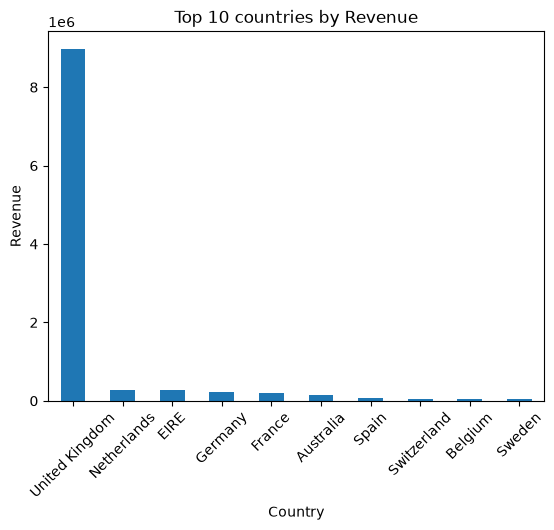

In [140]:
import matplotlib.pyplot as plt
top_countries_revenue.plot(kind="bar")
plt.title ("Top 10 countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

The United Kingdom generated substantially more revenue than the other countries in the top 10. The UK generated revenue in the millions of pounds, while most of the other countries generated revenue in the hundreds of thousands. This shows that the UK was by far the dominant revenue generating market in the dataset.

In [141]:
monthly_revenue = (df_sales.groupby("Month")["Revenue"].sum() )

In [142]:
monthly_revenue

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     735717.260
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

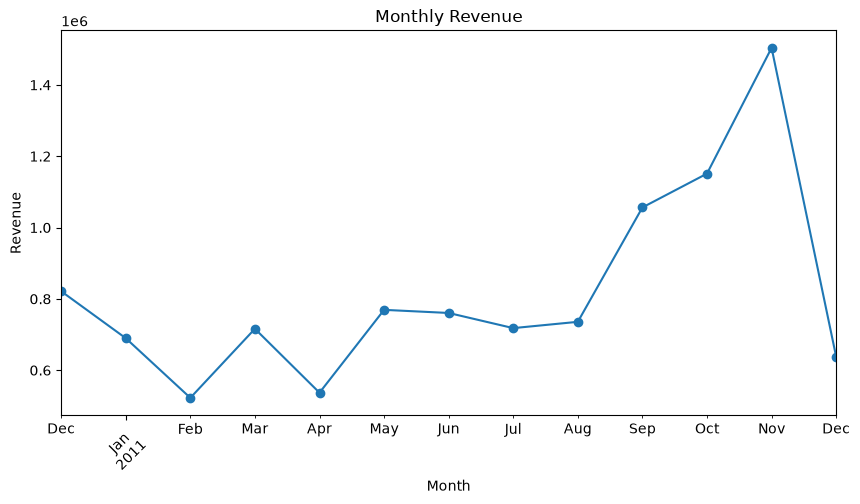

In [143]:
plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()



Revenue declined from December 2010 through February 2011. It increased in March before falling again in April. Revenue then rose in May and gradually declined through July. From August to November, revenue increased substantially, reaching its highest point of approximately £1.46 million in November. Revenue then fell sharply in December; however, December 2011 represents only part of the month because the dataset ends on December 9.

In [144]:
top_products_quantity = (
    df_sales.groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

StockCode
23843     80995
23166     78033
22197     56898
84077     54951
85099B    48375
85123A    41389
21212     36396
84879     36202
23084     30705
22492     26633
Name: Quantity, dtype: int64

In [145]:
df_sales[df_sales["StockCode"] == 23843]["Description"].unique()


array(['PAPER CRAFT , LITTLE BIRDIE'], dtype=object)

In [146]:
df_sales[df_sales["StockCode"] == "23843"]["UnitPrice"].unique()

array([], dtype=float64)

In [147]:
df_sales[
    df_sales["StockCode"].astype(str).str.strip() == "23843"
]["UnitPrice"].unique()

array([2.08])

In [148]:
top_products_revenue = (
    df_sales.groupby("StockCode")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue


StockCode
DOT       206248.77
22423     174156.54
23843     168469.60
85123A    104462.75
47566      99445.23
85099B     94159.81
23166      81700.92
POST       78101.88
M          77750.27
23084      66870.03
Name: Revenue, dtype: float64

In [149]:
df_sales[df_sales["StockCode"].isin(["DOT", "POST", "M"])]["Description"].unique()

array(['POSTAGE', 'DOTCOM POSTAGE', 'Manual', nan], dtype=object)

In [150]:
df_products = df_sales[
    ~df_sales["StockCode"].isin(["DOT", "POST", "M"])
].copy()

In [151]:
top_products_revenue = (
    df_products.groupby("StockCode")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

StockCode
22423     174156.54
23843     168469.60
85123A    104462.75
47566      99445.23
85099B     94159.81
23166      81700.92
23084      66870.03
22086      64875.59
84879      58927.62
79321      54096.36
Name: Revenue, dtype: float64

In [152]:
product_revenue = (
    df_products.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_revenue

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
23084      RABBIT NIGHT LIGHT                     66870.03
22086      PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
84879      ASSORTED COLOUR BIRD ORNAMENT          58927.62
79321      CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

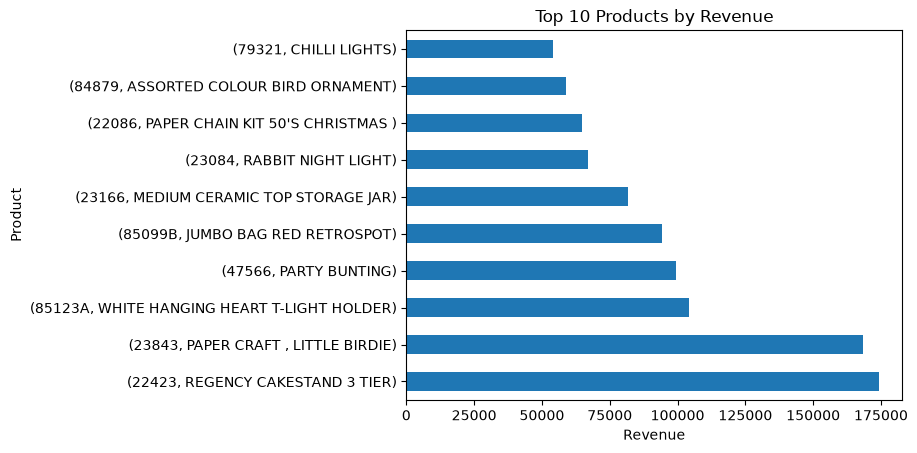

In [153]:
product_revenue.plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

The REGENCY CAKESTAND 3 TIER (StockCode 22423) was the highest revenue generating product, generating approximately €174,157 in revenue. PAPER CRAFT, LITTLE BIRDIE (StockCode 23843) ranked second with approximately €168,470, making it a close competitor to the leading product.

In [154]:
top_countries_transactions = (
    df_sales.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_countries_transactions

Country
United Kingdom    20122
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          95
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

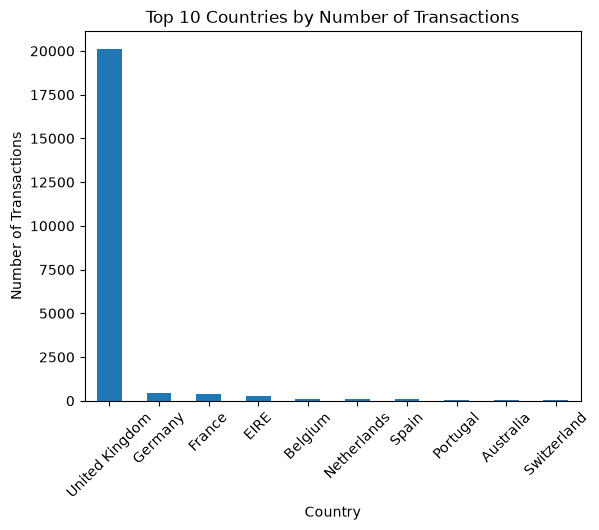

In [155]:
top_countries_transactions.plot(kind="bar")

plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [156]:
product_summary = (
    df_products.groupby("StockCode").agg(
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("Revenue", "sum")
    )
)

product_summary.head()

,TotalQuantity,TotalRevenue
StockCode,,
10002,1037,759.89
10080,495,119.09
10120,192,40.32
10125,1295,993.99
10133,2774,1539.60


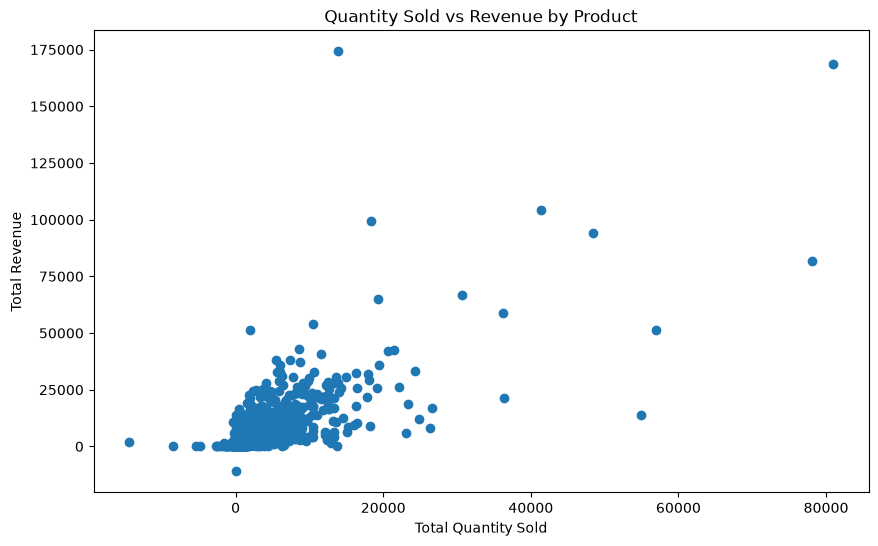

In [157]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_summary["TotalQuantity"],
    product_summary["TotalRevenue"]
)

plt.title("Quantity Sold vs Revenue by Product")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.show()

In [159]:
df_product_sales = df_products[
    (df_products["Quantity"] > 0) &
    (df_products["Revenue"] > 0)]. copy()

   

In [160]:
df_product_sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,20.34


In [162]:
product_summary_clean= (
    df_product_sales.groupby("StockCode").agg(
        TotalQuantity = ("Quantity", "sum"),
        TotalRevenue = ("Revenue", "sum")
    )
)

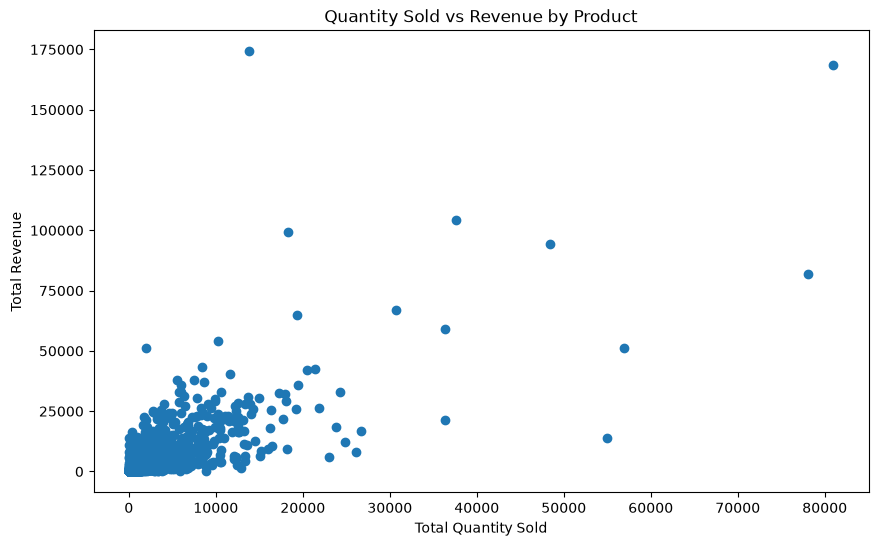

In [163]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_summary_clean["TotalQuantity"],
    product_summary_clean["TotalRevenue"]
)

plt.title("Quantity Sold vs Revenue by Product")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.show()